# Final Project in Machine Learning: Astronomical Object Classification

**Course:** Machine Learning - Final Project
**Authors:**
* [Shmuel Metzger] - [208773283]
* [Mordecai Yeshayahu] - [205447188]

## 1. Project Overview & Rationale
This notebook presents our final research project for the Machine Learning course. Our objective is to design, build, and evaluate a robust machine learning pipeline capable of solving a complex, multi-class classification problem using real-world data.

We selected the **Stellar Classification Dataset (SDSS17)**, which contains 100,000 spatial and spectral observations collected by the Sloan Digital Sky Survey. 

**The Practical Need:** Modern telescopes generate enormous amounts of input data (on the scale of Petabytes), and observation time on highly focused telescopes (like the James Webb Space Telescope) is an extremely expensive and scarce resource. Automated separation based on machine learning allows research systems to immediately filter out common objects and direct expensive analysis equipment toward more complex targets, without waiting for manual human processing.

## 2. The Physical Nature of the Target Classes
The ability to automatically and accurately distinguish between the three classes is a cornerstone of modern space research, due to the fundamental physical differences between them and how they emit energy:

* **Stars:** Independent plasma bodies that generate energy through nuclear fusion. Studying them allows us to understand the statistics, age, and chemical composition of individual celestial bodies. A star's light signature is mostly thermal emission depending on its surface temperature.
* **Galaxies:** Vast systems consisting of billions of stars, gas, and dust held together by gravity. Unlike a single star, a galaxy's light signature is complex and combines the spectra of all its constituent elements. Studying them is essential for understanding the evolution of the universe, researching dark matter, and mapping the large structures of the cosmos.
* **Quasars (QSO):** Active galactic nuclei with a supermassive black hole at their center that accretes matter and emits tremendous energy. Energetically, quasars are completely different from stars and regular galaxies; they emit massive and asymmetrical radiation across all wavelengths, creating a unique and extreme spectral signature.

In [1]:
# ==========================================
# Cell 1: Imports & Setup (Data Analysis Only)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings to ensure we can see all columns in the DataFrame
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

print("Libraries for Data Analysis loaded successfully!")

Libraries for Data Analysis loaded successfully!


### Purpose of Imported Libraries
At this stage of the research, we are focusing solely on loading, organizing, cleaning, and exploring the raw data. Therefore, we have imported the following libraries:

* **Pandas (`pd`):** Our core data manipulation library. It allows us to load the original CSV file (containing 100,000 observations) into a structured tabular format (DataFrame), remove irrelevant noise columns, and explore the data efficiently.
* **NumPy (`np`):** A powerful mathematical library working behind the scenes. It is used for fast numerical computations and array manipulations.
* **Matplotlib (`plt`) & Seaborn (`sns`):** Data visualization libraries. During the Exploratory Data Analysis (EDA) phase, we will use them to generate statistical charts (such as class distribution and redshift boxplots), allowing us to visually understand the data before moving on to the machine learning phase.

In [2]:
# ==========================================
# Cell 2: Load the Dataset & Inspect Features
# ==========================================

# Our notebook is in the 'notebooks' folder and the data is in the 'date' folder.
# We use a relative path to go up one level and into the 'date' directory.
data_path = '../date/star_classification.csv'

# Load the dataset
df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print(f"Initial shape: {df.shape}")
print("\nAll original features (columns) present in the dataset:")
print(df.columns.tolist())

# Display the first 5 rows to inspect the raw data
df.head()

Dataset loaded successfully!
Initial shape: (100000, 18)

All original features (columns) present in the dataset:
['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class', 'redshift', 'plate', 'MJD', 'fiber_ID']


,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


### Initial Data Inspection & Identifying Noise

As seen in the output above, our raw dataset contains 18 columns. However, after carefully inspecting the features, we identified that not all of them represent true physical properties of the astronomical objects. We recognized 9 administrative and technical features that are irrelevant to the actual physics of the stars, galaxies, or quasars:

* **`obj_ID`, `spec_obj_ID`:** Unique internal database serial numbers for the object and its optical spectrum.
* **`run_ID`, `rerun_ID`, `cam_col`, `field_ID`:** Technical telemetry describing which specific camera, scan line, and field of view the telescope used during the observation.
* **`plate`, `fiber_ID`, `MJD`:** Identifiers for the physical equipment (plug plate, optical fiber cable) used, and the exact chronological date of the observation (Modified Julian Date).

**Why must we drop them?**
These columns contain purely administrative metadata. If we leave them in, our machine learning algorithms (especially Decision Trees) might perform extreme **Overfitting**. The model could memorize random technical correlations (e.g., "Camera number 4 always captures stars") rather than learning the actual light and frequency signatures. To ensure our model learns real physics, we will drop these 9 columns in the next step.

In [3]:
# ==========================================
# Cell 3: Data Cleaning - Dropping Administrative Noise
# ==========================================

# List of the 9 columns identified as non-physical noise
noise_columns = [
    'obj_ID', 'spec_obj_ID', 
    'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 
    'plate', 'fiber_ID', 'MJD'
]

# Drop the irrelevant columns
df_clean = df.drop(columns=noise_columns)

print(f"Dataset shape after dropping noise: {df_clean.shape}")
print("\nRemaining physical and spatial features:")
print(df_clean.columns.tolist())

# Preview the clean dataset
df_clean.head()

Dataset shape after dropping noise: (100000, 9)

Remaining physical and spatial features:
['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'class', 'redshift']


,alpha,delta,u,g,r,i,z,class,redshift
0,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,GALAXY,0.634794
1,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,GALAXY,0.779136
2,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,GALAXY,0.644195
3,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,GALAXY,0.932346
4,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,GALAXY,0.116123


In [4]:
# ==========================================
# Cell 4: Statistical Summary (With Improved Color Styling)
# ==========================================

print("--- Class Distribution (Count) ---")
class_counts = df_clean['class'].value_counts()
print(class_counts)
print("\n" + "="*50 + "\n")

print("--- Max, Mean, and Min of Physical Features per Class ---")
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

# Calculate max, mean, and min
class_stats = df_clean.groupby('class')[numeric_cols].agg(['max', 'mean', 'min'])

# Move the statistics down to the rows and keep the order
formatted_stats = class_stats.stack(level=1).reindex(['max', 'mean', 'min'], level=1)

# Function to color rows based on the class with better contrast
def color_classes(row):
    class_name = row.name[0] # The index is a tuple: (Class, Stat)
    if class_name == 'GALAXY':
        return ['background-color: #B3E5FC; color: black; font-weight: 500'] * len(row) # Deeper Light Blue
    elif class_name == 'QSO':
        return ['background-color: #FFCDD2; color: black; font-weight: 500'] * len(row) # Deeper Light Red
    elif class_name == 'STAR':
        return ['background-color: #FFE0B2; color: black; font-weight: 500'] * len(row) # Deeper Light Orange
    return [''] * len(row)

# Apply the styling
styled_table = formatted_stats.style.apply(color_classes, axis=1)

# Display the styled table
display(styled_table)

--- Class Distribution (Count) ---
class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64


--- Max, Mean, and Min of Physical Features per Class ---


### Comprehensive EDA Conclusions & Data Quality Alert

Analyzing the statistical breakdown of our features reveals profound insights into the physical nature of our data and guides our next preprocessing steps:

**1. The Redshift Separation & Overlap:**
The `redshift` feature aligns strongly with astronomical theory: Stars show a near-zero mean, Galaxies a moderate positive mean (0.42), and Quasars a high mean (1.72). 
* **Crucial Overlap Observation:** Despite clear separation in *means*, examining the min/max values reveals a significant overlap (e.g., the maximum redshift of a Star heavily exceeds the minimum redshift of a QSO). A simple threshold on `redshift` alone will fail for edge cases, making the photometric light filters absolutely essential.

**2. The Photometric Filters & The Need for Color Indices:**
Looking at the raw photometric bands (`u`, `g`, `r`, `i`, `z`), their minimums, maximums, and means are quite close across all classes. 
* **Our Hypothesis:** While these raw values heavily overlap, we **retain** them because the true discriminative power lies in the *differences* between them. In astrophysics, these differences (e.g., u-g) are known as "Color Indices" representing the actual physical temperature and chemical signature. We will perform Feature Engineering later to explicitly calculate them.

**3. Spatial Coordinates Irrelevance (`alpha`, `delta`):**
Similar to the light filters, the descriptive statistics (min, mean, max) for `alpha` and `delta` are nearly identical across all three classes. However, unlike the light filters, we cannot extract deeper physical meaning from them. Combining this complete statistical uniformity with the physical reality that these are merely 2D viewing angles in the sky, we conclude they hold absolutely no predictive power. Retaining them would only cause **Spatial Overfitting** (forcing the model to memorize random sky maps). Therefore, they must be dropped.

**4. Class Imbalance Strategy:**
Our target variable is highly skewed. Galaxies make up the vast majority (~60%). Rather than discarding valuable data, we will preserve this natural distribution and handle it algorithmically during the modeling phase (e.g., using balanced class weights).

**5. Data Quality Alert (The -9999 Anomaly):**
In the **STAR** class, the minimum values for the `u`, `g`, and `z` bands drop to exactly `-9999.000000`. In the SDSS database, `-9999` is an artificial placeholder indicating a faulty sensor reading. If left untreated, the decision trees will interpret this as a valid extreme physical phenomenon, deeply distorting the training process.

In [5]:
# ==========================================
# Code Cell 5: Data Cleaning & Feature Engineering
# ==========================================

print(f"Original shape before processing: {df_clean.shape}")

# 1. Clean Sensor Errors: Filter out rows with -9999.0 in any photometric band
df_clean = df_clean[(df_clean['u'] != -9999.0) & 
                    (df_clean['g'] != -9999.0) & 
                    (df_clean['z'] != -9999.0)]
print(f"Shape after removing -9999 anomalies: {df_clean.shape}")

# 2. Feature Selection: Drop the non-predictive spatial coordinates
df_clean = df_clean.drop(columns=['alpha', 'delta'])
print(f"Shape after dropping 'alpha' and 'delta': {df_clean.shape}")

# 3. Feature Engineering: Creating Color Indices
# The difference between photometric bands represents the astronomical color (temperature/chemical signature)
df_clean['u_g'] = df_clean['u'] - df_clean['g']
df_clean['g_r'] = df_clean['g'] - df_clean['r']
df_clean['r_i'] = df_clean['r'] - df_clean['i']
df_clean['i_z'] = df_clean['i'] - df_clean['z']

print(f"Final shape after Feature Engineering: {df_clean.shape}")
print("\nCurrent features ready for analysis:")
print(df_clean.columns.tolist())

Original shape before processing: (100000, 9)
Shape after removing -9999 anomalies: (99999, 9)
Shape after dropping 'alpha' and 'delta': (99999, 7)
Final shape after Feature Engineering: (99999, 11)

Current features ready for analysis:
['u', 'g', 'r', 'i', 'z', 'class', 'redshift', 'u_g', 'g_r', 'r_i', 'i_z']


In [6]:
# ==========================================
# Code Cell 6: Statistical Summary on Processed Data
# ==========================================

print("--- New Max, Mean, and Min of Features per Class ---")

# Select only numeric columns for the new table
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

# Calculate max, mean, and min
class_stats = df_clean.groupby('class')[numeric_cols].agg(['max', 'mean', 'min'])

# Move the statistics down to the rows and keep the order
formatted_stats = class_stats.stack(level=1).reindex(['max', 'mean', 'min'], level=1)

# Function to color rows based on the class with good contrast
def color_classes(row):
    class_name = row.name[0]
    if class_name == 'GALAXY':
        return ['background-color: #B3E5FC; color: black; font-weight: 500'] * len(row)
    elif class_name == 'QSO':
        return ['background-color: #FFCDD2; color: black; font-weight: 500'] * len(row)
    elif class_name == 'STAR':
        return ['background-color: #FFE0B2; color: black; font-weight: 500'] * len(row)
    return [''] * len(row)

# Apply the styling
styled_table = formatted_stats.style.apply(color_classes, axis=1)

# Display the styled table
display(styled_table)

--- New Max, Mean, and Min of Features per Class ---


### Post-Engineering Data Analysis & Validation

Following our data cleaning and feature engineering phase, a review of the updated statistical summary confirms the success of our preprocessing strategy:

**1. Successful Anomaly Resolution:**
The artificial `-9999.0` sensor errors have been entirely removed from the dataset. Observing the `min` row for the **STAR** class, the minimum values for the `u`, `g`, and `z` bands are now realistic, positive physical measurements (e.g., `12.10`, `10.49`, `9.61`). The dataset is now strictly bounded by valid astronomical observations, completely eliminating the risk of numerical distortion during model training.

**2. The Predictive Power of Color Indices (Feature Validation):**
Our core hypothesis—that the *differences* between photometric bands hold more discriminative power than their raw intensities—is strongly validated by the new calculated features (`u_g`, `g_r`, `r_i`, `i_z`):
* **Capturing Unique Spectral Signatures:** Analyzing the mean of the new `u_g` (ultraviolet minus green) feature reveals a stark contrast. Quasars (QSO) show a drastically lower mean (`0.62`) compared to Galaxies (`1.68`) and Stars (`1.53`). This mathematically isolates the physical reality that Quasars emit disproportionately high levels of ultraviolet radiation due to supermassive black hole accretion.
* **Enhanced Separability:** While the raw individual light bands exhibited heavily overlapping means across all classes, the engineered Color Indices create much clearer statistical boundaries. We have successfully extracted the "color temperature" and chemical signatures of the objects, equipping our future Machine Learning models with highly effective splitting criteria.

**3. Readiness for Visualization and Modeling:**
With the deceptive spatial coordinates removed and the raw light intensities augmented into meaningful physical metrics, our dataset is now pristine. Every remaining column represents a pure, objective astrophysical property. The data is now fully prepared for Exploratory Visual Analysis (Graphs) and subsequent predictive modeling.

C:\Users\shmue\AppData\Local\Temp\ipykernel_14520\4155933859.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='class', palette=custom_palette, ax=axes[0], order=['GALAXY', 'STAR', 'QSO'])


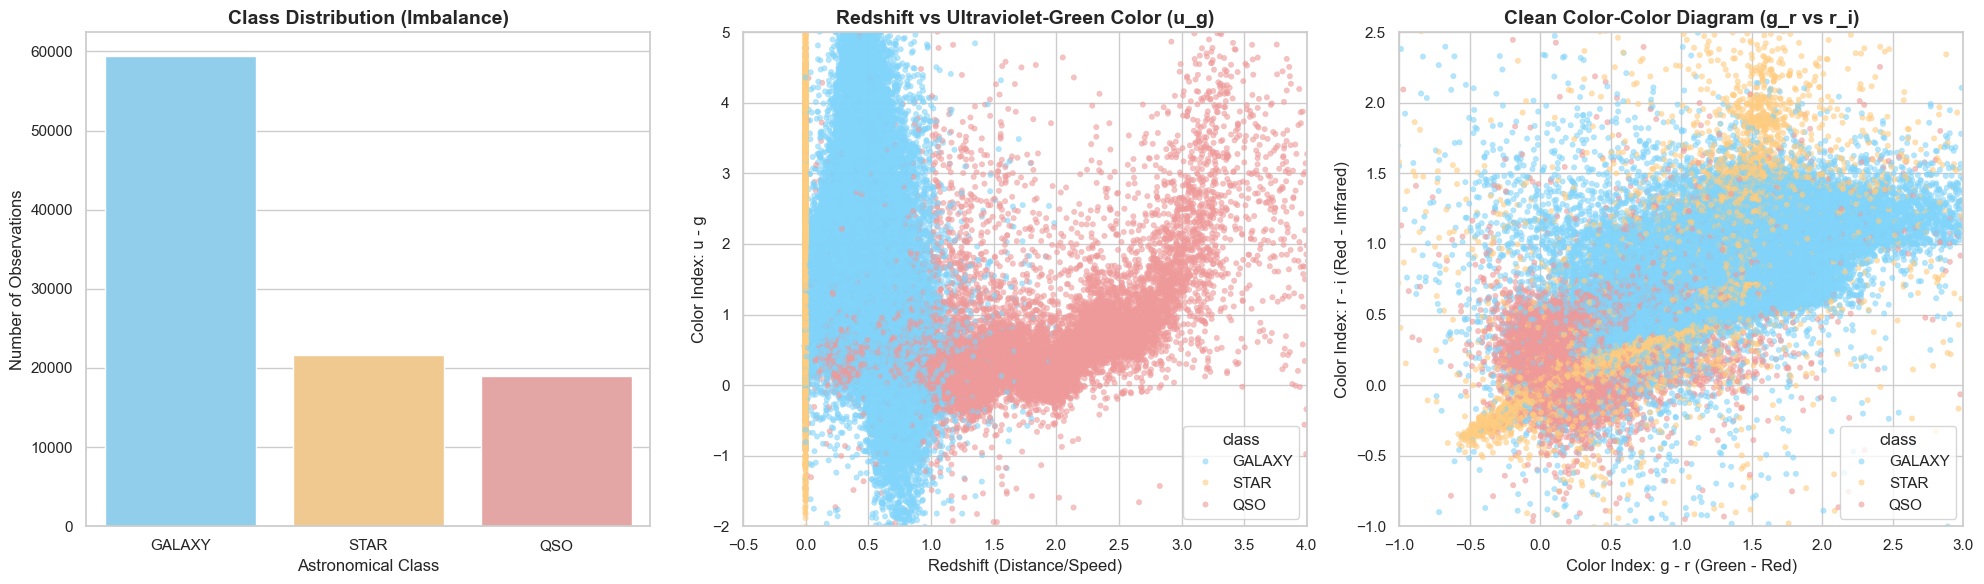

In [7]:
# ==========================================
# Code Cell 7: Data Visualization (Updated Visual EDA)
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

# Define a custom color palette
custom_palette = {'GALAXY': '#81D4FA', 'QSO': '#EF9A9A', 'STAR': '#FFCC80'}

# Create a figure with 3 subplots side by side
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Class Distribution
sns.countplot(data=df_clean, x='class', palette=custom_palette, ax=axes[0], order=['GALAXY', 'STAR', 'QSO'])
axes[0].set_title('Class Distribution (Imbalance)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Observations')
axes[0].set_xlabel('Astronomical Class')

# 2. Scatter: Redshift vs u_g (Replaces Boxplot)
sns.scatterplot(data=df_clean, x='redshift', y='u_g', hue='class', palette=custom_palette, 
                s=15, alpha=0.6, edgecolor=None, ax=axes[1], hue_order=['GALAXY', 'STAR', 'QSO'])
axes[1].set_title('Redshift vs Ultraviolet-Green Color (u_g)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Redshift (Distance/Speed)')
axes[1].set_ylabel('Color Index: u - g')
# Zoom in on the meaningful data cluster, ignoring extreme outliers
axes[1].set_xlim(-0.5, 4) 
axes[1].set_ylim(-2, 5)   

# 3. Clean Color-Color Diagram: g_r vs r_i
sns.scatterplot(data=df_clean, x='g_r', y='r_i', hue='class', palette=custom_palette, 
                s=15, alpha=0.6, edgecolor=None, ax=axes[2], hue_order=['GALAXY', 'STAR', 'QSO'])
axes[2].set_title('Clean Color-Color Diagram (g_r vs r_i)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Color Index: g - r (Green - Red)')
axes[2].set_ylabel('Color Index: r - i (Red - Infrared)')
# Zoom in to see the 'Main Sequence' of stars and galaxies clearly
axes[2].set_xlim(-1, 3)
axes[2].set_ylim(-1, 2.5)

plt.tight_layout()
plt.show()

### Visual Exploratory Data Analysis (EDA) & Physical Interpretations

The visual representation of our pristine dataset perfectly validates our prior statistical conclusions and clearly maps out the challenges our machine learning models will face:

**1. Class Imbalance (Left/First Panel):**
The bar chart visually confirms the heavy skew in our dataset. Galaxies form the overwhelming majority. This visualizes the necessity of choosing the right evaluation metrics later on (such as Macro F1-Score rather than raw accuracy), ensuring our model doesn't simply bias toward predicting "GALAXY".

**2. Redshift vs. Ultraviolet-Green Color (Middle Panel):**
* **Why `u_g`?** The `u_g` index measures the difference between Ultraviolet (`u`) and Green (`g`) light. Extremely hot and energetic objects emit heavily in the UV spectrum. 
* **Observation:** Plotting `redshift` against `u_g` vividly demonstrates why quasars (QSO) are unique: they violently break away from the local cluster, stretching far into high redshift territory while maintaining a distinct `u_g` signature (due to the extreme energy of their supermassive black holes). However, zooming in on the left side (redshift ~0) reveals a dense, overlapping cluster of Stars and Galaxies. This proves that while `redshift` alone isolates Quasars easily, it fails to separate local Stars from nearby Galaxies.

**3. Clean Color-Color Diagram (Right/Last Panel - `g_r` vs `r_i`):**
* **Why these specific colors?** The `u` (Ultraviolet) and `z` (Infrared) filters are highly sensitive to atmospheric noise and cosmic dust. By plotting `g_r` (Green-Red) against `r_i` (Red-Near IR), we focus on the peak thermal emission of typical celestial bodies, recreating a classic, stable astronomical "Color-Color Diagram".
* **Addressing the Overlap (הערבוב בגרף):** At first glance, this graph appears heavily mixed, with classes densely overlapping. A simple human-drawn threshold cannot separate them. However, looking closely, the points do not scatter randomly; they form distinct diagonal sub-clusters and bands (representing the "Main Sequence" of stellar temperatures). 
* **Conclusion for Machine Learning:** While the heavy visual overlap makes 2D separation nearly impossible, it is actually a strong indicator of success for our upcoming models. Algorithms like Decision Trees and Ensemble methods will analyze *all* these color indices alongside redshift simultaneously in a multi-dimensional space, effortlessly untangling these complex clusters.

In [8]:
# ==========================================
# Code Cell 8: Target Encoding & 3-Way Stratified Split (65-25-10)
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("--- Finalizing Data Preparation ---")

# 1. Encode the target variable (Strings to 0, 1, 2)
le = LabelEncoder()
df_clean['class_encoded'] = le.fit_transform(df_clean['class'])

class_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f"Class Mapping: {class_mapping}")

# Drop the original string 'class' column as it's no longer needed
df_clean = df_clean.drop(columns=['class'])

# 2. First Split: Extract the Final Holdout Test set (10%) and the Development set (90%)
# NOTE: We are splitting the ENTIRE dataframe (Features + Target combined).
dev_df, test_df = train_test_split(df_clean, test_size=0.10, random_state=42, stratify=df_clean['class_encoded'])

# 3. Second Split: Divide the Development set (90%) into Train (65%) and Validation (25%)
train_df, val_df = train_test_split(dev_df, test_size=(25/90), random_state=42, stratify=dev_df['class_encoded'])

print("\n--- Final Stratified Data Splits ---")
print(f"Training Set (65%):   {train_df.shape}")
print(f"Validation Set (25%): {val_df.shape}")
print(f"Final Test Set (10%): {test_df.shape}")

--- Finalizing Data Preparation ---
Class Mapping: {'GALAXY': np.int64(0), 'QSO': np.int64(1), 'STAR': np.int64(2)}

--- Final Stratified Data Splits ---
Training Set (65%):   (64999, 11)
Validation Set (25%): (25000, 11)
Final Test Set (10%): (10000, 11)


### Stratified 3-Way Data Split Rationale (65% / 25% / 10%)

In this stage, we execute a **Stratified 3-Way Data Split**, dividing our processed dataset into **Training (65%)**, **Validation (25%)**, and a **Final Holdout Test (10%)** subsets. 

#### 1. Rationale for the 65-25-10 Distribution Ratio
* **Training Set (65%):** Allocates a substantial foundation of approximately 65,000 observations for the models to robustly learn the physical boundaries and spectral signatures.
* **Validation Set (25%):** A larger validation partition (approx. 25,000 observations) provides a highly stable environment for hyperparameter tuning and model comparison.
* **Final Test Set (10%):** Acts as a strict holdout set (approx. 10,000 observations). This remains completely locked during development, serving exclusively at the very end to provide an unbiased measure of our finalized model's capabilities.
* **The Training Strategy:** We will train on the 65% set and evaluate on the 25% set. Ultimately, the best model will be retrained on the entire Development Set (Train + Validation, 90%) before facing the 10% test challenge.

#### 2. The Critical Necessity of Stratification (`stratify=class_encoded`)
By enforcing a **Stratified Split**, we strictly compel the algorithm to mirror the exact **60/20/20** natural class proportion across all three sets. This guarantees that every subset remains a perfect statistical representation of the original population, preventing minority classes (Quasars/Stars) from being underrepresented in the evaluation phase.

#### 3. Architectural Note: Keeping Features (X) and Target (y) Together
*Notice that we did not split our DataFrame into `X` (features) and `y` (target) before applying the split.* We intentionally split the entire unified DataFrame. This engineering choice is made to preserve the row-level integrity of the data for an easy and clean CSV export in the next step. Separating the features from the target variable will be handled dynamically at the beginning of the Model Building notebook, strictly prior to the learning phase.

In [9]:
# ==========================================
# Code Cell 9: Exporting Processed Data Splits
# ==========================================

import os

print("--- Exporting Data Splits to CSV ---")

# Define the target directory (going up one level to the 'date' folder)
output_dir = '../date/'

# Ensure the directory exists
os.makedirs(output_dir, exist_ok=True)

# Define clear filenames highlighting the data contained
files_to_save = {
    'train_data_65.csv': train_df,
    'validation_data_25.csv': val_df,
    'test_data_10.csv': test_df
}

# Save each dataframe, checking for existing files to maintain order and prevent mess
for filename, df in files_to_save.items():
    filepath = os.path.join(output_dir, filename)
    
    # Check if file exists to inform the user
    if os.path.exists(filepath):
        print(f"[*] Overwriting existing file: '{filename}'")
    else:
        print(f"[+] Creating new file: '{filename}'")
        
    # Save to CSV without the dataframe index
    df.to_csv(filepath, index=False)

print("\nData Analysis & Preparation Notebook Completed Successfully!")
print("Files are securely stored in the '../date/' folder.")

--- Exporting Data Splits to CSV ---
[+] Creating new file: 'train_data_65.csv'
[+] Creating new file: 'validation_data_25.csv'
[+] Creating new file: 'test_data_10.csv'

Data Analysis & Preparation Notebook Completed Successfully!
Files are securely stored in the '../date/' folder.


### Data Export & Pipeline Decoupling

To ensure a robust and modular machine learning pipeline, we conclude this notebook by exporting our finalized, preprocessed datasets (with features and targets safely bound together). 

We saved them as dedicated CSV files within the project's `date` directory:
* `train_data_65.csv`
* `validation_data_25.csv`
* `test_data_10.csv`

**The Engineering Advantage:** This effectively decouples our Data Preparation phase from our Model Building phase. Future notebooks or scripts can directly load these pristine files without needing to re-execute any data cleaning, splitting, or engineering logic.